In [ ]:
!pip install llama-index
!pip install newsapi-python

The main idea of ReAct prompt behind:
```
Thought: The current language of the user is: (user's language). I need to use a tool to help me answer the question.
```
```
Action: tool name (one of {tool_names}) if using a tool.
```
```
Action Input: the input to the tool, in a JSON format representing the kwargs (e.g. {{"input": "hello world", "num_beams": 5}})
```
```
Observation: tool response
```


```
Thought: I can answer without using any more tools. I'll use the user's language to answer
Answer: [your answer here (In the same language as the user's question)]
```

```
Thought: I cannot answer the question with the provided tools.
Answer: [your answer here (In the same language as the user's question)]
```



In [ ]:
from llama_index.core.agent import ReActAgent
from llama_index.llms.openai import OpenAI
from llama_index.core.llms import ChatMessage
from llama_index.core.tools import BaseTool, FunctionTool

In [ ]:
from google.colab import userdata
NEWS_API_KEY = userdata.get('NEWS_API_KEY')

from newsapi import NewsApiClient
newsapi = NewsApiClient(api_key=NEWS_API_KEY)

openai_api_key = userdata.get('OPENAI_API_KEY')
# import openai
# openai.api_key = openai_api_key
llm = OpenAI(model="gpt-4-1106-preview",api_key=openai_api_key)

In [ ]:
#to check the llm
llm.complete("Hello").text

'Hello! How can I assist you today?'

In [ ]:
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from datetime import date
import pandas as pd

# Tools Spec

In [ ]:
from llama_index.core.tools.tool_spec.base import BaseToolSpec
import yfinance as yf
import pandas as pd


class FinanceTools(BaseToolSpec):
    """Finance tools spec."""

    spec_functions = [
        "stock_prices",
        "last_stock_price",
        "search_news",
        "summarize_news_news_api",
        "plot_stock_price"
    ]

    def __init__(self) -> None:
        """Initialize the Yahoo Finance tool spec."""

    def stock_prices(self, ticker: str) -> pd.DataFrame:
            """
            Get the historical prices and volume for a ticker for the last month.

            Args:
              ticker (str): the stock ticker to be given to yfinance

            """
            stock = yf.Ticker(ticker)
            df = stock.history()
            return df

    def last_stock_price(self, ticker: str) -> pd.DataFrame:
            """
            Get the last historical prices and volume for a ticker.

            Args:
              ticker (str): the stock ticker to be given to yfinance

            """
            stock = yf.Ticker(ticker)
            df = stock.history()
            df_last = df.iloc[-1:]
            return df_last


    def search_news(self, ticker: str, num_articles:int =5, from_datetime = "2024-04-10",to_datetime = date.today()):

      """
      Get the most recent news of a stock or an instrument

      Args:
        ticker (str): the stock ticker to be given to NEWSAPI
        num_articles (int): Number of news article to collect
      """

      all_articles = newsapi.get_everything(q=ticker,
                                            from_param=from_datetime,
                                            to=to_datetime,
                                            language='en',
                                            sort_by='relevancy',
                                            page_size=num_articles)

      news_concat =  [
            f"{article['title']}, {article['description']}, {article['content'][0:100]}"
            for article in all_articles['articles']
        ]

      return (".\n").join(news_concat)


    def summarize_news_news_api(self, ticker: str) -> str:
            """
            Summarize the news of a given stock or an instrument

            Args:
              news (str): the news articles to be summarized for a given instruments.

            """
            news = self.search_news(ticker)
            prompt = f"Summarize the following text by extractin the key insights: {news}"
            response = llm.complete(prompt).text
            return response


    def plot_stock_price(self, ticker: str, list_column:list =['Close','Volume']) -> pd.DataFrame:
        """
        For a given ticker symbol plot the different values given in list_column during the last month .

        Args:
          ticker (str): the stock ticker to be given to yfinance
          list_column (list): the different columns to plot. It could be Close, Open, High, Volume.

        """
        df = self.stock_prices(ticker)

        columns = [col.upper() for col in df.columns]
        df.columns = columns
        list_column = [col.upper() for col in list_column]

        df[list_column].plot(title=f'{ticker} Historical Data')

        plt.xlabel('Date')
        plt.ylabel('Price')
        plt.show()
        return 'Plotted'


# Create ReAct Agent with Finance Tools

In [ ]:
finance_tool = FinanceTools()

finance_tool_list = finance_tool.to_tool_list()
for tool in finance_tool_list:
    print(tool.metadata.name)

agent = ReActAgent.from_tools(finance_tool_list, llm=llm, verbose=True)

stock_prices
last_stock_price
search_news
summarize_news_news_api
plot_stock_price


# Chat with the Agent

## What is the last price of Nvidia?

In [ ]:
response = agent.chat("What is the last price of Nvidia?")

Thought: The user is asking for the most recent stock price of Nvidia. I will use the last_stock_price tool to retrieve this information.
Action: last_stock_price
Action Input: {'ticker': 'NVDA'}
Observation:                                  Open        High         Low       Close  \
Date                                                                        
2024-04-16 00:00:00-04:00  864.330017  881.179993  860.640015  874.150024   

                             Volume  Dividends  Stock Splits  
Date                                                          
2024-04-16 00:00:00-04:00  36908300        0.0           0.0  
Thought: I can answer without using any more tools. I'll use the user's language to answer.
Answer: The last price of Nvidia (NVDA) was $874.15.


## What are the latest news about Apple?

In [ ]:
response = agent.chat("What are the latest news about Apple?")

Thought: The user is asking for the latest news about Apple Inc. I will use the search_news tool to find the most recent news articles related to Apple's stock ticker, which is AAPL.
Action: search_news
Action Input: {'ticker': 'AAPL', 'num_articles': 5}
Observation: Judge in Apple antitrust case steps down, due to apparent conflict of interest, The judge due to hear the Apple antitrust case brought by the US Department of Justice has recused himself, meaning that he will no longer preside over the case.



Judge Michael E. Farbiarz yesterday filed paperwork stating that his recusal is “necessary” un…, The judge due to hear the Appleantitrust case brought by the US Department of Justice has recused hi.
Apple Can’t Recover, Bloomberg reports that “Apple Is Rebooting Its Search for a New Next Big Thing.” The problem for the huge consumer electronics company is that there isn’t one. Apple Inc. (NASDAQ: AAPL) is trapped by its reliance on a few major hardware products, an operating…, Bloom

## Give me a summary about the latest news about OpenAI?

In [ ]:
response = agent.chat("Give me a summary about the latest news about OpenAI?")

Thought: The current language of the user is English. I need to use a tool to help me summarize the latest news about OpenAI.
Action: summarize_news_news_api
Action Input: {'ticker': 'OPENAI'}
Observation: Adobe Premiere Pro is incorporating new generative AI video tools, including its own Firefly generative AI video model and potential third-party integrations from companies like OpenAI, Pika Labs, and Runway. Additionally, OpenAI has updated its ChatGPT model to be more direct and less verbose for premium users, enhancing the user experience for those using ChatGPT Plus, Team, or Enterprise services.
Thought: I can answer without using any more tools. I'll use the user's language to answer.
Answer: The latest news about OpenAI includes Adobe Premiere Pro integrating new generative AI video tools, with potential third-party integrations from OpenAI and others. OpenAI has also updated its ChatGPT model to provide a more direct and less verbose experience for premium users of ChatGPT Pl

## Give me the last month historical data of BTCUSD?

In [ ]:
response = agent.chat("Give me the last month historical data of BTCUSD?")

Thought: The user is asking for the historical data of the Bitcoin to US Dollar (BTCUSD) exchange rate for the last month. I will use the stock_prices tool to retrieve this information.
Action: stock_prices
Action Input: {'ticker': 'BTC-USD'}
Observation:                                    Open          High           Low  \
Date                                                                  
2024-03-17 00:00:00+00:00  65316.343750  68845.718750  64545.316406   
2024-03-18 00:00:00+00:00  68371.304688  68897.132812  66594.226562   
2024-03-19 00:00:00+00:00  67556.132812  68106.929688  61536.179688   
2024-03-20 00:00:00+00:00  61930.156250  68115.257812  60807.785156   
2024-03-21 00:00:00+00:00  67911.585938  68199.992188  64580.917969   
2024-03-22 00:00:00+00:00  65489.929688  66623.750000  62355.371094   
2024-03-23 00:00:00+00:00  63802.722656  65976.398438  63038.492188   
2024-03-24 00:00:00+00:00  64070.753906  67622.757812  63825.851562   
2024-03-25 00:00:00+00:00  67234.0

In [ ]:
print(response)

The historical data for Bitcoin against the US Dollar (BTCUSD) for the last month shows various opening, high, low, and closing prices along with the volume of transactions for each day. On the most recent date in the data provided, April 17, 2024, Bitcoin opened at $63,826.06, reached a high of $64,442.62, a low of $63,222.05, and closed at $63,222.05. The volume of transactions on that day was 38,423,281,664.


The historical data for Bitcoin against the US Dollar (BTCUSD) for the last month shows various opening, high, low, and closing prices along with the volume of transactions for each day. On the most recent date in the data provided, April 17, 2024, Bitcoin opened at \$63,826.06, reached a high of \$64,442.62, a low of \$63,222.05, and closed at \$63,222.05. The volume of transactions on that day was 38,423,281,664.

## Before I added the plot_stock_price method to the list of the tools, I asked the agent to plot the stock prices:

1/ The agent gets the historical prices.  2/As there is no tool defined enabling the agent to plot, it defaults in its basic behavior by answer the question coming from its own knowledge and proposing a python code implementation with matplotlib

In [ ]:
response = agent.chat("Plot the close prices of Nvidia?")

Thought: The user is asking for a visual representation of the closing prices for Nvidia. I need to use the stock_prices tool to retrieve the historical prices for Nvidia.
Action: stock_prices
Action Input: {'ticker': 'NVDA'}
Observation:                                  Open        High         Low       Close  \
Date                                                                        
2024-03-18 00:00:00-04:00  903.880005  924.049988  870.849976  884.549988   
2024-03-19 00:00:00-04:00  867.000000  905.440002  850.099976  893.979980   
2024-03-20 00:00:00-04:00  897.969971  904.099976  882.229980  903.719971   
2024-03-21 00:00:00-04:00  923.000000  926.479980  904.049988  914.349976   
2024-03-22 00:00:00-04:00  911.409973  947.780029  908.340027  942.890015   
2024-03-25 00:00:00-04:00  939.409973  967.659973  935.099976  950.020020   
2024-03-26 00:00:00-04:00  958.510010  963.750000  925.020020  925.609985   
2024-03-27 00:00:00-04:00  931.119995  932.400024  891.229980  902.5

## After adding plot_stock_price (which returns the value "Plotted") function to the list of the tools, I get the following plot:

Thought: The user is asking for a plot of the close prices of Nvidia over the last month. I will use the plot_stock_price tool to generate this plot.
Action: plot_stock_price
Action Input: {'ticker': 'NVDA', 'list_column': ['Close']}


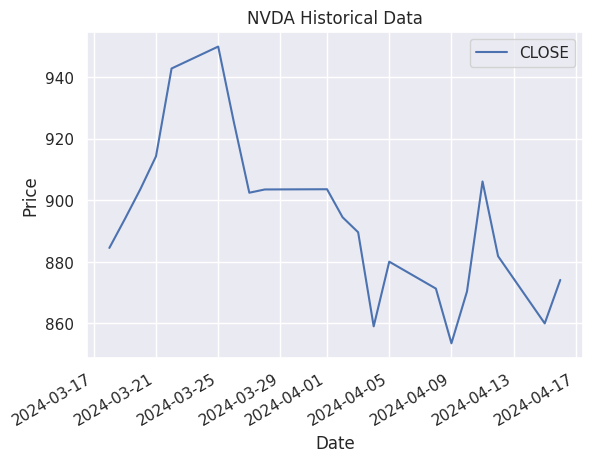

Observation: Plotted
Thought: The user has observed the plotted close prices of Nvidia, so no further action is required unless the user has additional questions or requests.
Answer: If you have any more questions or need further assistance, feel free to ask!


In [ ]:
response = agent.chat("Plot the close prices of Nvidia?")

## After adding plot_stock_price (without RETURN ) function to the list of the tools:

The agent struggle at the beggining at ending the observation. At each time it founds "None" until it rollbacks on the historical prices "stock_prices" function. This is good because, it tries and when it cannot if finds another solution.

Thought: The user is asking for a plot of the closing prices for Nvidia, which has the ticker symbol NVDA. I will use the plot_stock_price tool to generate this plot.
Action: plot_stock_price
Action Input: {'ticker': 'NVDA', 'list_column': ['Close']}


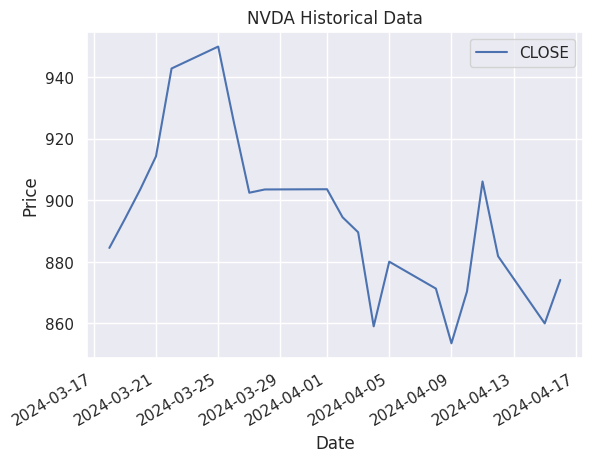

Observation: None
Thought: It seems there was an issue with the previous action, as the user reported no observation, which indicates that the plot was not provided. I will attempt to use the plot_stock_price tool again to generate the plot of the closing prices for Nvidia.
Action: plot_stock_price
Action Input: {'ticker': 'NVDA', 'list_column': ['Close']}


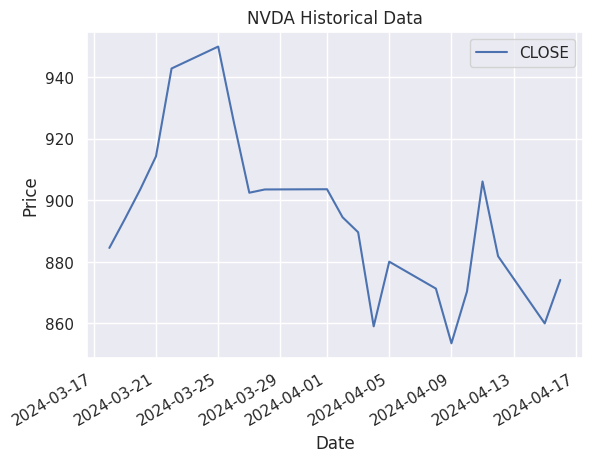

Observation: None
Thought: There appears to be a persistent issue with generating the plot as the user has again reported no observation. Since the plot_stock_price tool is not providing the expected output, I will attempt a different approach by retrieving the historical prices using the stock_prices tool and then manually creating a plot if necessary.
Action: stock_prices
Action Input: {'ticker': 'NVDA'}
Observation:                                  Open        High         Low       Close  \
Date                                                                        
2024-03-18 00:00:00-04:00  903.880005  924.049988  870.849976  884.549988   
2024-03-19 00:00:00-04:00  867.000000  905.440002  850.099976  893.979980   
2024-03-20 00:00:00-04:00  897.969971  904.099976  882.229980  903.719971   
2024-03-21 00:00:00-04:00  923.000000  926.479980  904.049988  914.349976   
2024-03-22 00:00:00-04:00  911.409973  947.780029  908.340027  942.890015   
2024-03-25 00:00:00-04:00  939.409973 

In [ ]:
response = agent.chat("Plot the close prices of Nvidia?")

# LLamaIndex Template under the hood

In [ ]:
prompt_dict = agent.get_prompts()
for k, v in prompt_dict.items():
    print(f"Prompt: {k}\n\nValue: {v.template}")

Prompt: agent_worker:system_prompt

Value: You are designed to help with a variety of tasks, from answering questions to providing summaries to other types of analyses.

## Tools

You have access to a wide variety of tools. You are responsible for using the tools in any sequence you deem appropriate to complete the task at hand.
This may require breaking the task into subtasks and using different tools to complete each subtask.

You have access to the following tools:
{tool_desc}


## Output Format

Please answer in the same language as the question and use the following format:

```
Thought: The current language of the user is: (user's language). I need to use a tool to help me answer the question.
Action: tool name (one of {tool_names}) if using a tool.
Action Input: the input to the tool, in a JSON format representing the kwargs (e.g. {{"input": "hello world", "num_beams": 5}})
```

Please ALWAYS start with a Thought.

Please use a valid JSON format for the Action Input. Do NOT do t